Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.984418 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [4.60e+01, 4.90e-01]    [5.19e+01, 4.90e-01]    [1.52e+00]    


/home/hridoy/miniconda3/envs/torch-env/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


1000      [4.73e-04, 4.50e-07]    [5.80e-04, 4.50e-07]    [6.18e-04]    
2000      [9.32e-05, 1.09e-07]    [2.11e-04, 1.09e-07]    [3.81e-04]    
3000      [3.80e-05, 3.46e-08]    [1.16e-04, 3.46e-08]    [1.77e-04]    
4000      [6.26e-05, 4.19e-06]    [9.04e-05, 4.19e-06]    [1.95e-03]    
5000      [1.74e-05, 2.45e-07]    [6.37e-05, 2.45e-07]    [3.76e-04]    
6000      [1.96e-04, 1.04e-06]    [2.50e-04, 1.04e-06]    [1.65e-03]    
7000      [2.21e-05, 9.95e-07]    [8.05e-05, 9.95e-07]    [8.04e-04]    
8000      [5.68e-05, 1.54e-06]    [1.31e-04, 1.54e-06]    [1.13e-03]    
9000      [1.79e-04, 9.30e-06]    [1.76e-04, 9.30e-06]    [3.08e-03]    
10000     [1.05e-04, 8.85e-06]    [1.01e-04, 8.85e-06]    [2.61e-03]    

Best model at step 5000:
  train loss: 1.76e-05
  test loss: 6.40e-05
  test metric: [3.76e-04]

'train' took 25.336115 s



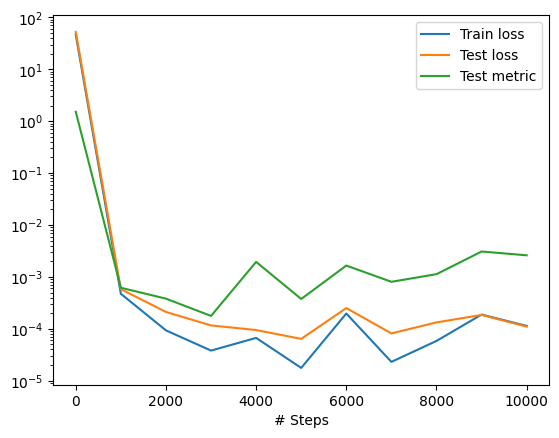

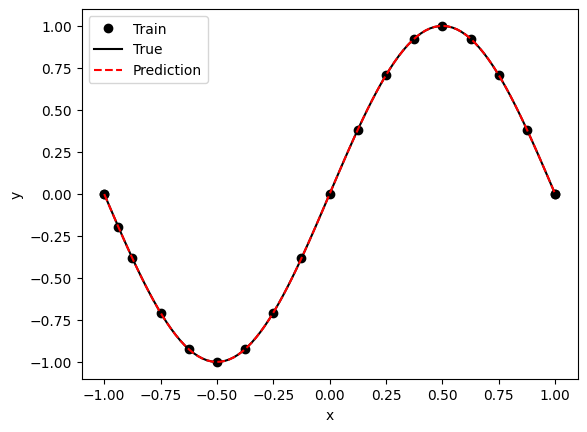

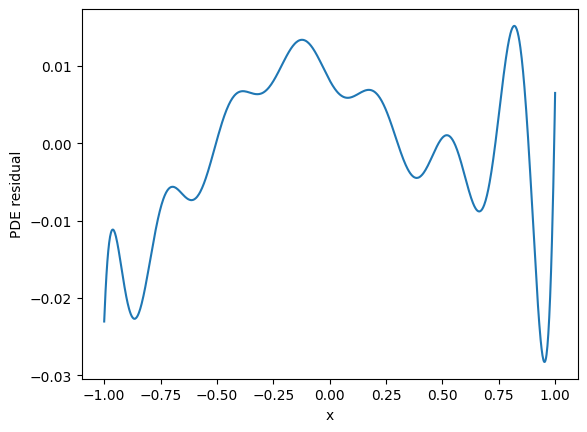

In [1]:
import deepxde as dde
import matplotlib.pyplot as plt
import numpy as np
import torch

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)

    return -dy_xx - np.pi ** 2 * torch.sin(np.pi * x)


def boundary(x, on_boundary):
    return on_boundary

def func(x):
    return np.sin(np.pi * x)

geom = dde.geometry.Interval(-1, 1)
bc = dde.icbc.DirichletBC(geom, func, boundary)
data = dde.data.PDE(geom, pde, bc, 16, 2, solution=func, num_test=100)

layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
innitializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, innitializer)

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations=10000)

dde.saveplot(losshistory, train_state, issave=False, isplot=True)

x = geom.uniform_points(1000, True)
y = model.predict(x, operator=pde)
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("PDE residual")
plt.show()

